In [3]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [5]:
df = sns.load_dataset('dowjones')
df.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


In [6]:
df.shape

(649, 2)

In [7]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

RMSE Error: 21.64


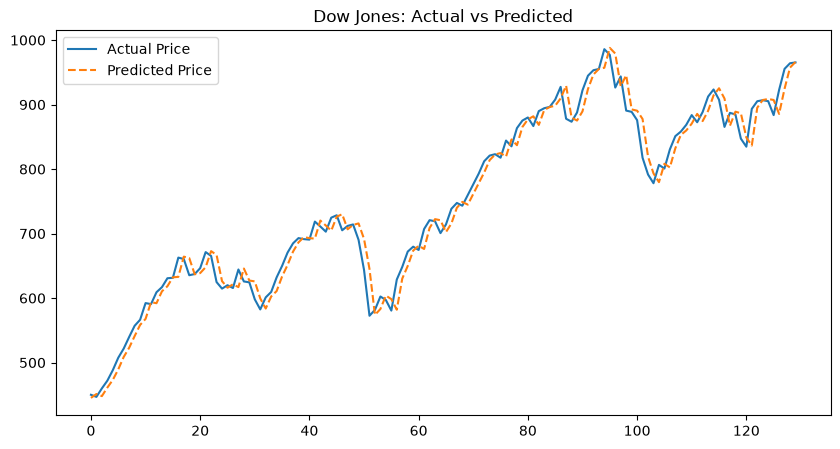

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Pichhle month ka price (Lag_1 feature) create karna
df['Lag_1'] = df['Price'].shift(1)
data = df.dropna()

# 2. X (Features) aur y (Target) define karna
X = data[['Lag_1']]
y = data['Price']

# 3. Train-Test Split (Time-series me shuffle nahi karte)
train_size = int(len(data) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 4. Model train aur predict karna
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. Error check karna (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE Error: {rmse:.2f}")

# 6. Actual vs Predicted ka graph plot karna
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price', linestyle='--')
plt.title('Dow Jones: Actual vs Predicted')
plt.legend()
plt.show()